# Hotel Booking Analysis — Understanding Booking & Cancellation Behaviour
[![GitHub Repo](https://img.shields.io/badge/GitHub-Repository-181717?style=flat&logo=github)](https://github.com/JDMalkerion/hotel-booking-analysis)
## Project Summary

The goal of this project is to perform exploratory data analysis (EDA) on a hotel booking dataset covering 2017–2019, focusing on understanding what drives guests to book and what drives them to cancel. The analysis answers three business questions: which hotel type is booked most often, whether length of stay affects cancellation rate, and whether lead time (the gap between booking and arrival) affects cancellation rate. Findings are turned into concrete pricing, staffing, and cancellation-policy recommendations for a hotel manager.

**Key steps:**

**Data Preprocessing:** The dataset (~119K rows × 29 columns) was cleaned by handling missing values in columns like `company`, `agent`, `children`, and `city`, checking for duplicate rows, resolving inconsistent values (e.g. `'Undefined'` in `meal`), and addressing anomalies such as extreme `adr` values and bookings with zero guests. Every cleaning decision is justified inline.

**Data Visualization:** Bar charts, pie charts, and line charts were used to explore hotel type share, monthly booking trends by hotel type, cancellation rate by stay duration, and cancellation rate by lead time bucket — each split by hotel type where relevant.

**Insights:**
- City Hotel is booked roughly twice as often as Resort Hotel (66.4% vs. 33.6%), with both types sharing a seasonal peak in September–October and a trough in January–March.
- City Hotel's cancellation rate (41.8%) is well above Resort Hotel's (27.8%), and this gap widens sharply with both stay length (up to 67.1% at 10+ nights) and lead time (up to 64.1% at 180+ days).
- Resort Hotel cancellation behavior stays comparatively flat regardless of stay length or lead time, making it a lower-risk, more predictable segment than City Hotel.
- The highest-risk segment identified is City Hotel bookings made 180+ days in advance, which cancel nearly two-thirds of the time — the single largest, most actionable finding in the analysis.

This EDA provides actionable information for pricing, staffing, and cancellation-policy decisions. Hotel managers and revenue strategists can use these findings to grow the less-popular hotel type, capitalize on peak seasons, and reduce cancellations tied to long stays and long lead times.


> **Note on notebook structure:** Throughout Stage 1 (Data Preprocessing), code cells fall into two categories: *diagnostic* cells (marked with a `####` sub-header, e.g. "Exploratory check...") that investigate a data quality question, and *decision* cells that apply the cleaning action justified by the diagnostic immediately before it. This separation is intentional — it keeps the reasoning behind each cleaning decision visible and traceable, rather than applying fixes without showing the evidence that motivated them.

#### Exploratory check: confirm column list and dataset shape

In [4]:
import pandas as pd
df = pd.read_csv('data/hotel_bookings_data.csv')
df.shape

(119390, 29)

#### Exploratory check: confirm date range and column types

In [5]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_weekdays_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'city',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status']

#### Exploratory check: verify `city` values before assuming country-level data

In [6]:
df['city'].nunique()
df['city'].value_counts().head(10)

city
Kota Denpasar                 48590
Kabupaten Bangka              12129
Kota Yogyakarta               10415
Kota Batu                      8568
Kabupaten Bandung              7287
Kabupaten Kepulauan Seribu     3766
Kota Malang                    3375
Kabupaten Magelang             2342
Kota Jakarta Barat             2224
Kabupaten Belitung             2104
Name: count, dtype: int64

#### Exploratory check: confirm date range and column types

In [7]:
print(df['arrival_date_year'].min(), '-', df['arrival_date_year'].max())
df[['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_weekdays_nights', 'arrival_date_month']].dtypes

2017 - 2019


hotel                         str
is_canceled                 int64
lead_time                   int64
stays_in_weekend_nights     int64
stays_in_weekdays_nights    int64
arrival_date_month            str
dtype: object

### 1.1 Data Overview

The dataset contains **119,390 rows and 29 columns**, covering hotel bookings from **2017 to 2019**.

The columns most relevant to the three business questions are:

- **`hotel`** — City Hotel or Resort Hotel; the core split for the "which hotel type is booked most" question.
- **`is_canceled`** — binary flag (1 = cancelled, 0 = not cancelled); the target variable for both the stay-duration and lead-time cancellation questions.
- **`lead_time`** — number of days between booking date and arrival date; used directly in the lead-time-vs-cancellation analysis.
- **`stays_in_weekend_nights`** and **`stays_in_weekdays_nights`** — combined to calculate total length of stay, used in the stay-duration-vs-cancellation analysis.
- **`arrival_date_month`** (and `arrival_date_year`) — used to analyze monthly booking volume and seasonality by hotel type.

#### Missing value diagnosis

In [8]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
city                                 488
children                               4
is_canceled                            0
arrival_date_month                     0
arrival_date_week_number               0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
stays_in_weekdays_nights               0
lead_time                              0
arrival_date_year                      0
hotel                                  0
meal                                   0
babies                                 0
adults                                 0
market_segment                         0
previous_cancellations                 0
previous_bookings_not_canceled         0
distribution_channel                   0
is_repeated_guest                      0
deposit_type                           0
booking_changes                        0
days_in_waiting_list                   0
customer_type   

In [9]:
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['city'] = df['city'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

# confirm no missing values remain in these columns
df[['company', 'agent', 'city', 'children']].isnull().sum()

company     0
agent       0
city        0
children    0
dtype: int64

**Missing values:**

- `company` (94% missing) and `agent` (14% missing) are ID codes, not free-text fields — a missing value almost certainly means the booking wasn't made through a company or agent respectively, rather than data loss. Filled with `0` to represent "not applicable."
- `city` (488 rows, <1%) likely reflects an undisclosed or uncaptured guest location. Filled with `"Unknown"` rather than dropped, to avoid losing otherwise-complete booking records over one missing field.
- `children` (4 rows) is too small a gap to investigate meaningfully; filled with `0` as the most defensible default.

#### Duplicate investigation: are these real bookings or data errors?

In [10]:
df.duplicated().sum()

np.int64(33261)

In [14]:
df[df.duplicated(keep=False)]['market_segment'].value_counts()

market_segment
Groups           17122
Offline TA/TO    12564
Online TA         8625
Corporate         1577
Direct            1513
Complementary       93
Aviation            19
Name: count, dtype: int64

In [15]:
df[df.duplicated(keep=False)]['adults'].value_counts()

adults
2    32000
1     8962
3      511
0       36
4        4
Name: count, dtype: int64

#### Baseline comparison: duplicate rows vs. full dataset

In [16]:
df['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.473046
Offline TA/TO    0.202856
Groups           0.165935
Direct           0.105587
Corporate        0.044350
Complementary    0.006223
Aviation         0.001985
Undefined        0.000017
Name: proportion, dtype: float64

In [17]:
df['adults'].value_counts(normalize=True)

adults
2     0.751152
1     0.192872
3     0.051947
0     0.003375
4     0.000519
26    0.000042
27    0.000017
20    0.000017
5     0.000017
40    0.000008
50    0.000008
55    0.000008
6     0.000008
10    0.000008
Name: proportion, dtype: float64

**Duplicate rows:**

`df.duplicated().sum()` found **33,261 duplicate rows (~28% of the dataset)**. Because this dataset has no booking ID or guest ID column, an identical row could mean either a data-entry error or a legitimate separate booking (e.g. a family or group booking multiple identical rooms on the same dates at the same rate).

To distinguish between these, I compared the market segment distribution of duplicate rows against the dataset overall:

- `Groups` makes up **16.6%** of all bookings, but **41%** of duplicate rows — a 2.5x overrepresentation.
- `adults` count distribution is nearly identical between duplicates and the overall dataset (~75% vs ~77% at `adults == 2`), so it doesn't distinguish the two.

The market segment skew toward `Groups` supports the interpretation that a large share of these duplicates are legitimate multi-room group bookings rather than data errors. **Decision: retain all duplicate rows**, since dropping them would discard a substantial number of real bookings based on an unverifiable assumption.

#### Meal value inconsistency check

In [18]:
df['meal'].value_counts()

meal
Breakfast     92310
Dinner        14463
No Meal       10650
Undefined      1169
Full Board      798
Name: count, dtype: int64

In [19]:
df['meal'] = df['meal'].replace('Undefined', 'No Meal')

# confirm
df['meal'].value_counts()

meal
Breakfast     92310
Dinner        14463
No Meal       11819
Full Board      798
Name: count, dtype: int64

**Inconsistent values — `meal` column:**

This dataset labels meal packages as `Breakfast`, `Dinner`, `No Meal`, and `Full Board`, rather than the standard `BB`/`HB`/`SC`/`FB` codes. 1,169 rows (~1%) were labeled `'Undefined'`. Per standard hotel booking data dictionaries, an undefined/missing meal package typically indicates no meal plan was selected — equivalent to this dataset's `'No Meal'` category. Merged `'Undefined'` into `'No Meal'` accordingly.

#### Anomaly diagnosis: `adr` and zero-guest rows

In [20]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [21]:
(df['adults'] + df['children'] + df['babies'] == 0).sum()

np.int64(180)

In [22]:
(df['adr'] < 0).sum()
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
14969,Resort Hotel,0,195,2019,May,10,5,4,6,2,...,2,No Deposit,273.0,0.0,0,Family,-6.38,0,0,Check-Out


In [23]:
df[df['adr'] > 1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
48515,City Hotel,1,35,2018,May,13,25,0,1,2,...,1,Non Refund,12.0,0.0,0,Personal,5400.0,0,0,Canceled


In [24]:
df[(df['adults'] + df['children'] + df['babies']) == 0]['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.861111
1    0.138889
Name: proportion, dtype: float64

In [25]:
df['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

- **Zero-guest rows:** 180 rows recorded zero adults, children, and babies. Only 13.9% of these were cancelled, compared to a 37% baseline cancellation rate across the full dataset — meaning these bookings mostly proceeded to a completed stay, indicating a data logging gap in the guest-count fields rather than a distinct booking type or junk data. Dropped, as they cannot be reliably used in any guest-count-related analysis and represent a negligible 0.15% of the dataset.

#### Applying cleanup decisions

In [26]:
# Negative adr — data entry error (single row), drop
df = df[df['adr'] >= 0]

# Extreme adr outlier — single row, cancelled booking, disproportionate to rest of distribution, drop
df = df[df['adr'] <= 5000]

# Zero-guest rows — guest count field unreliable for these rows, drop
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

df.shape

(119208, 29)

In [27]:
hotel_counts = df['hotel'].value_counts()
print(hotel_counts)
print(hotel_counts / hotel_counts.sum() * 100)

hotel
City Hotel      79162
Resort Hotel    40046
Name: count, dtype: int64
hotel
City Hotel      66.406617
Resort Hotel    33.593383
Name: count, dtype: float64


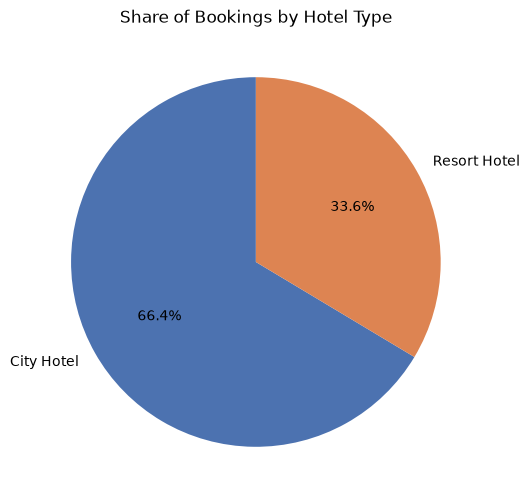

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%', 
       colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('Share of Bookings by Hotel Type')
plt.savefig('images/hotel_type_share.png', bbox_inches='tight', dpi=150)
plt.show()

*City Hotel accounts for 66.4% of all bookings, roughly twice the share of Resort Hotel (33.6%) — City Hotel is the more frequently booked property type by a wide margin.*

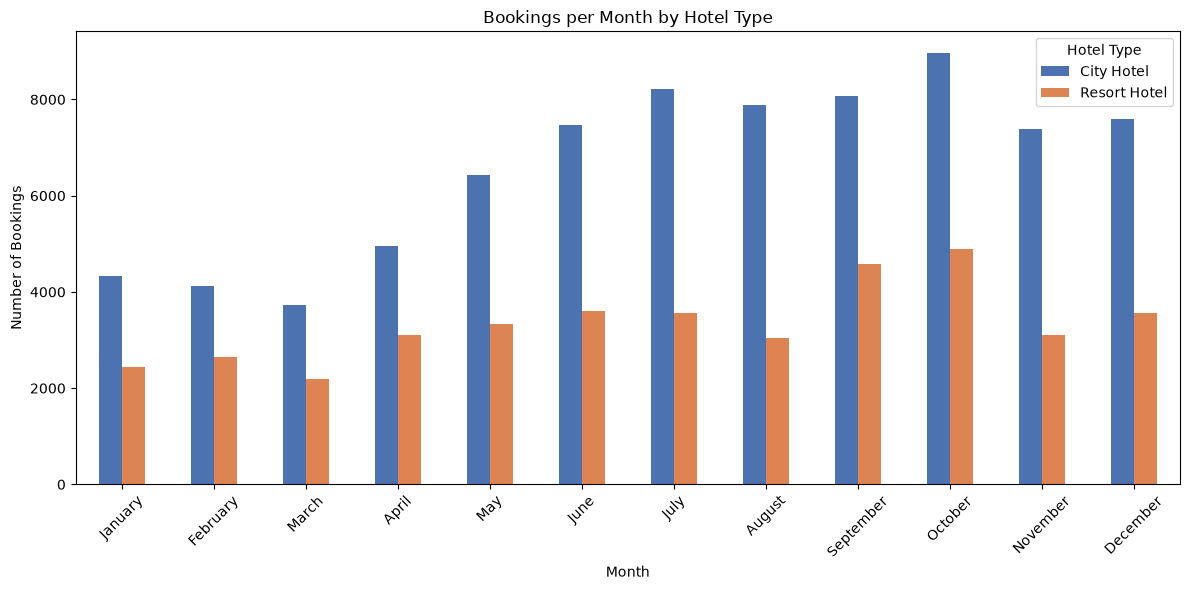

In [31]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_bookings = df.groupby(['arrival_date_month', 'hotel']).size().unstack()
monthly_bookings = monthly_bookings.reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 6))
monthly_bookings.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Bookings per Month by Hotel Type')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')
ax.legend(title='Hotel Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/monthly_bookings_by_hotel.png', bbox_inches='tight', dpi=150)
plt.show()

*Both hotel types follow a similar seasonal shape rather than diverging — bookings are lowest from January to March and peak in September–October for both City and Resort Hotel, with a minor dip in August. This suggests demand is driven by a shared seasonal factor (e.g. dry-season travel, school holidays, or a shoulder-season surge) rather than City and Resort hotels serving distinct, opposite travel patterns.*

### 2.1.3 — Explaining the seasonal pattern

The dominant location in this dataset is Kota Denpasar (Bali), which sees international and domestic leisure tourism peak during Indonesia's dry season (roughly April–October) — this aligns closely with the rise in bookings from April onward and the September–October peak. The January–March trough falls within Indonesia's wet season, when travel to Bali and similar destinations is typically less attractive.

The fact that City and Resort hotels move together, rather than opposing each other, suggests the underlying driver is a shared national travel pattern (dry-season tourism, school holiday timing) rather than distinct city-business-travel vs. resort-leisure-travel cycles — the classic pattern assumed in hotel datasets tied to European or North American markets doesn't fully apply here given Bali's dominance in this dataset.

### 2.1.4 — Operational and revenue implications

- **Staffing:** Ramp up front-desk and housekeeping staffing ahead of the September–October peak; the January–March trough is a natural window for maintenance, renovations, or staff leave.
- **Pricing:** Dynamic pricing should lean into the shared peak — since both hotel types peak together, pricing strategy can be coordinated across the portfolio rather than needing to offset a resort peak against a city trough.
- **Marketing spend:** Concentrate promotional spend in the January–March low season, when demand needs the most help, rather than during the September–October peak when rooms likely sell without extra push.

In [32]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
print(cancel_by_hotel)

hotel
City Hotel      41.785200
Resort Hotel    27.768067
Name: is_canceled, dtype: float64


In [34]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_weekdays_nights']

df['total_nights'].describe()

count    119208.000000
mean          3.426213
std           2.540633
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_nights, dtype: float64

In [35]:
(df['total_nights'] >= 10).sum()
df['total_nights'].max()

np.int64(69)

In [36]:
def night_bucket(n):
    if n <= 3:
        return '0-3'
    elif n <= 7:
        return '4-7'
    elif n <= 10:
        return '8-10'
    else:
        return '10+'

df['night_bucket'] = df['total_nights'].apply(night_bucket)

bucket_order = ['0-3', '4-7', '8-10', '10+']
cancel_by_nights = df.groupby('night_bucket')['is_canceled'].mean().reindex(bucket_order) * 100
print(cancel_by_nights)

night_bucket
0-3     37.724802
4-7     35.918487
8-10    35.474593
10+     36.641221
Name: is_canceled, dtype: float64


hotel         City Hotel  Resort Hotel
night_bucket                          
0-3            42.674978     23.814752
4-7            38.707590     32.148213
8-10           48.795944     30.982906
10+            67.129630     28.725962


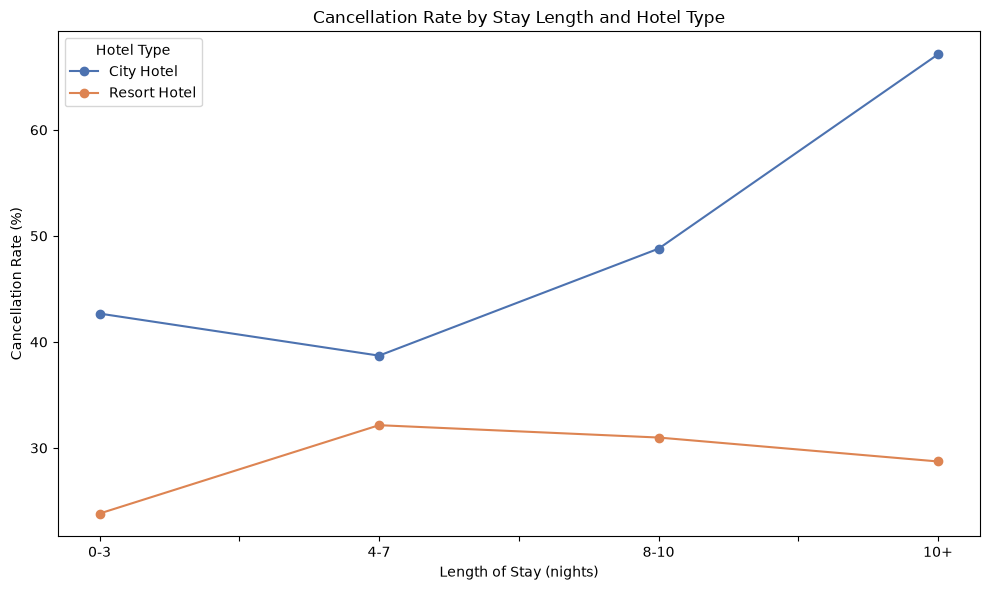

In [38]:
cancel_by_nights_hotel = df.groupby(['night_bucket', 'hotel'])['is_canceled'].mean().unstack().reindex(bucket_order) * 100
print(cancel_by_nights_hotel)

fig, ax = plt.subplots(figsize=(10, 6))
cancel_by_nights_hotel.plot(kind='line', marker='o', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Cancellation Rate by Stay Length and Hotel Type')
ax.set_xlabel('Length of Stay (nights)')
ax.set_ylabel('Cancellation Rate (%)')
ax.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig('images/cancellation_by_stay_length.png', bbox_inches='tight', dpi=150)
plt.show()

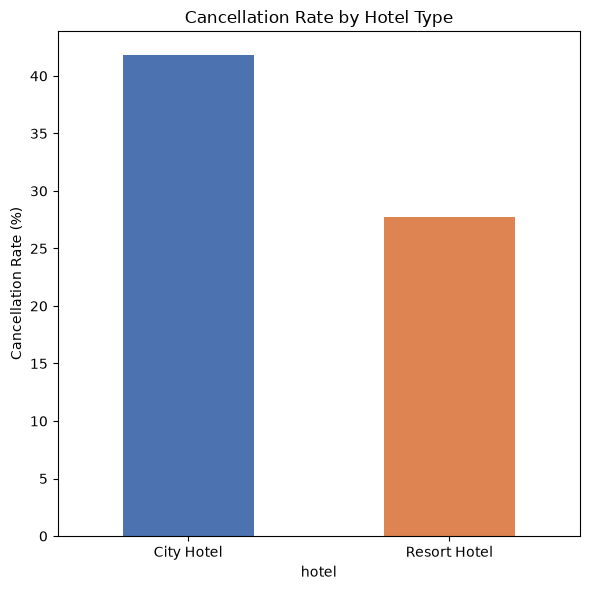

In [39]:
fig, ax = plt.subplots(figsize=(6, 6))
cancel_by_hotel.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Cancellation Rate by Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xticklabels(cancel_by_hotel.index, rotation=0)
plt.tight_layout()
plt.savefig('images/cancellation_rate_by_hotel.png', bbox_inches='tight', dpi=150)
plt.show()

**Cancellation rate by hotel type:** City Hotel bookings are cancelled at **41.8%**, compared to **27.8%** for Resort Hotel — a 14-point gap.

**Trend across stay length:** Combining both hotel types, cancellation rate looks roughly flat (35–38%) across all stay lengths. However, splitting by hotel type reveals this flatness is misleading — it's the average of two opposing trends. **City Hotel cancellation rate rises sharply with stay length**, from 42.7% (0–3 nights) to 67.1% (10+ nights). **Resort Hotel stays comparatively stable**, hovering between 24–32% regardless of length. The relationship is therefore **positive for City Hotel** and **flat-to-slightly-negative for Resort Hotel** — the two hotel types do not behave the same way.

**Possible reasons for the difference:**
1. Long stays at a City Hotel are more likely tied to business trips or extended plans that are prone to change (rescheduled meetings, project timelines shifting), making cancellation more likely the longer the booking window.
2. Resort bookings are more likely pre-planned leisure/vacation trips (often booked further in advance with deposits or non-refundable terms), which may carry a stronger commitment to follow through regardless of stay length.

In [40]:
df['lead_time'].describe()

count    119208.000000
mean        104.109045
std         106.875835
min           0.000000
25%          18.000000
50%          69.000000
75%         161.000000
max         737.000000
Name: lead_time, dtype: float64

hotel             City Hotel  Resort Hotel
lead_time_bucket                          
0-7                12.183500      6.504702
8-30               30.938522     21.908182
31-90              39.947052     32.457443
91-180             48.028123     37.436085
180+               64.066836     41.585949


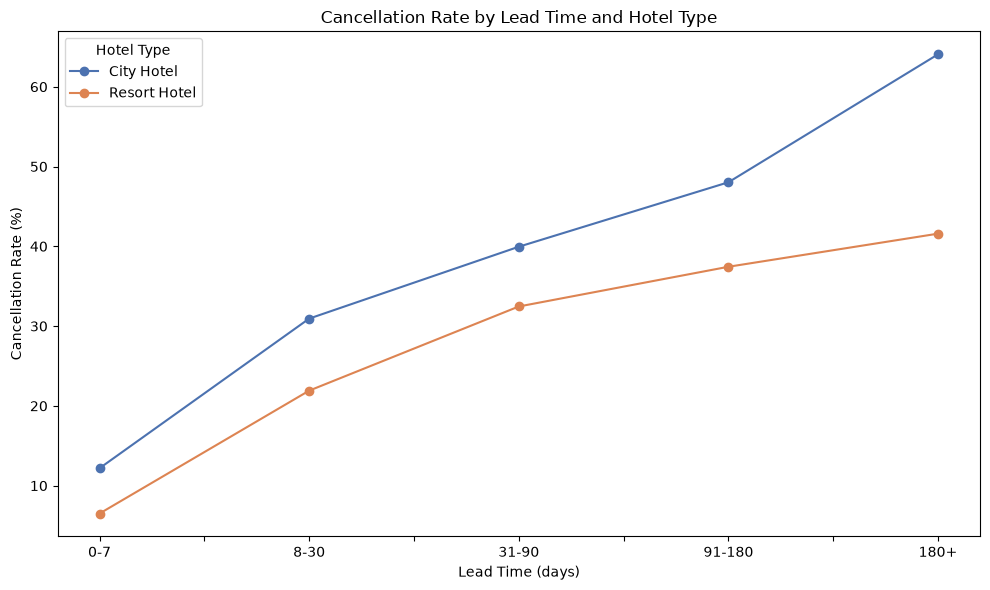

In [41]:
def lead_time_bucket(n):
    if n <= 7:
        return '0-7'
    elif n <= 30:
        return '8-30'
    elif n <= 90:
        return '31-90'
    elif n <= 180:
        return '91-180'
    else:
        return '180+'

df['lead_time_bucket'] = df['lead_time'].apply(lead_time_bucket)

lt_bucket_order = ['0-7', '8-30', '31-90', '91-180', '180+']
cancel_by_leadtime_hotel = df.groupby(['lead_time_bucket', 'hotel'])['is_canceled'].mean().unstack().reindex(lt_bucket_order) * 100
print(cancel_by_leadtime_hotel)

fig, ax = plt.subplots(figsize=(10, 6))
cancel_by_leadtime_hotel.plot(kind='line', marker='o', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Cancellation Rate by Lead Time and Hotel Type')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Cancellation Rate (%)')
ax.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig('images/cancellation_by_lead_time.png', bbox_inches='tight', dpi=150)
plt.show()

**Lead time defined:** Lead time is the number of days between when a booking is made and the guest's arrival date — a short lead time means booking close to the stay, a long lead time means booking far in advance.

**Where cancellation is lowest/highest:** Cancellation is lowest in the 0–7 day bucket for both hotel types (City Hotel 12.2%, Resort Hotel 6.5%) — bookings made just before arrival are rarely cancelled. Cancellation is highest at 180+ days lead time, and City Hotel is the clear outlier here at **64.1%** — nearly two-thirds of far-ahead City Hotel bookings are eventually cancelled, compared to 41.6% for Resort Hotel in the same bucket.

**Comparing the two hotel types:** Both hotel types show the same overall direction — cancellation rate rises steadily as lead time increases — but City Hotel rises much more sharply. The gap between the two types widens from about 6 points at short lead times to 22 points at 180+ days. This mirrors the pattern seen in Stage 2.2 (stay duration): City Hotel bookings are consistently more fragile the further out they're planned, while Resort Hotel bookings hold up more reliably regardless of how far in advance they were made. This could reflect that resort trips are often vacations booked with more commitment (deposits, travel plans already locked in), whereas

## Stage 3 — Summary and Recommendations

### 1. Summary of key findings across all three analyses

**Hotel type popularity**

![Share of Bookings by Hotel Type](images/hotel_type_share.png)
![Bookings per Month by Hotel Type](images/monthly_bookings_by_hotel.png)

City Hotel accounts for 66.4% of all bookings, roughly twice the share of Resort Hotel (33.6%) — City Hotel is the more frequently booked property type by a wide margin. Both hotel types follow a similar seasonal shape rather than diverging — bookings are lowest from January to March and peak in September–October for both City and Resort Hotel, with a minor dip in August. This suggests demand is driven by a shared seasonal factor rather than City and Resort hotels serving distinct, opposite travel patterns. Given the Indonesian cities in this dataset (Bali/Denpasar dominant, alongside Yogyakarta, Batu, and Bandung), this pattern likely reflects Indonesia's dry season (roughly April–October), when travel to Bali and similar destinations is most attractive, with the January–March trough falling in the wet season.

**Stay duration and cancellation**

![Cancellation Rate by Hotel Type](images/cancellation_rate_by_hotel.png)
![Cancellation Rate by Stay Length and Hotel Type](images/cancellation_by_stay_length.png)

City Hotel bookings are cancelled at 41.8%, compared to 27.8% for Resort Hotel — a 14-point gap. Combining both hotel types, cancellation rate looks roughly flat (35–38%) across all stay lengths — but this flatness is misleading, since it's the average of two opposing trends. City Hotel cancellation rate rises sharply with stay length, from 42.7% (0–3 nights) to 67.1% (10+ nights). Resort Hotel stays comparatively stable, hovering between 24–32% regardless of length. Possible reasons: long stays at a City Hotel are more likely tied to business trips or extended plans prone to change (rescheduled meetings, shifting project timelines), making cancellation more likely the longer the booking window. Resort bookings are more likely pre-planned leisure trips, often booked with deposits or non-refundable terms, which may carry a stronger commitment to follow through regardless of stay length.

**Lead time and cancellation**

![Cancellation Rate by Lead Time and Hotel Type](images/cancellation_by_lead_time.png)

Lead time is the number of days between when a booking is made and the guest's arrival date. Cancellation is lowest in the 0–7 day bucket for both hotel types (City Hotel 12.2%, Resort Hotel 6.5%) — bookings made just before arrival are rarely cancelled. Cancellation is highest at 180+ days lead time, and City Hotel is the clear outlier here at 64.1% — nearly two-thirds of far-ahead City Hotel bookings are eventually cancelled, compared to 41.6% for Resort Hotel in the same bucket. Both hotel types rise steadily with lead time, but the gap between them widens from about 6 points at short lead times to 22 points at 180+ days — this mirrors the pattern seen in stay duration, where City Hotel bookings are consistently more fragile the further out they're planned, while Resort Hotel holds up more reliably. This could reflect that resort trips are often vacations booked with more commitment, whereas City Hotel bookings — often business or flexible travel — are easier to cancel or rebook as plans shift.

---

### 2. Hotel type & seasonality recommendations

![Bookings per Month by Hotel Type](images/monthly_bookings_by_hotel.png)

- **Staffing:** Ramp up front-desk and housekeeping staffing ahead of the September–October peak; the January–March trough is a natural window for maintenance, renovations, or staff leave.
- **Grow the less-popular hotel type:** Run targeted promotions for Resort Hotel during the September–October peak, when overall demand is already elevated, to help close the popularity gap with City Hotel (currently outbooked 2-to-1).
- **Capitalize on peak seasons:** Since both hotel types peak together, pricing strategy can be coordinated across the portfolio rather than needing to offset a resort peak against a city trough — lean into dynamic pricing during September–October.
- **Marketing spend:** Concentrate promotional spend in the January–March low season, when demand needs the most help, rather than during the peak when rooms likely sell without extra push.

---

### 3. Stay duration & cancellation policy recommendations

![Cancellation Rate by Stay Length and Hotel Type](images/cancellation_by_stay_length.png)

- Introduce tiered, non-refundable deposits for City Hotel stays of 8+ nights, scaling with stay length — this segment cancels at 49–67%, the single largest cancellation-rate escalation found in the data.
- Avoid extending fully flexible long-stay rates for City Hotel; pair any minimum-stay discount with firmer cancellation terms so the discount doesn't compound the existing cancellation risk in that segment.
- Since Resort Hotel's cancellation rate stays flat regardless of stay length, minimum-stay incentives (e.g. discounts for 7+ night bookings) can be extended there with comparatively low added risk.

---

### 4. Lead time & cancellation policy recommendations

![Cancellation Rate by Lead Time and Hotel Type](images/cancellation_by_lead_time.png)

- Require a deposit at time of booking (not check-in) for City Hotel bookings made 180+ days in advance — this bucket cancels 64.1% of the time, nearly two-thirds of all such bookings.
- Send staged reminder/confirmation emails (e.g. at 90, 30, and 7 days before arrival) for long-lead-time bookings, giving guests an easy rebooking or modification path instead of an outright cancellation.
- Since Resort Hotel's lead-time cancellation curve is comparatively gentler, deposit requirements there can be introduced at a later threshold (e.g. 180+ days only) rather than applied as broadly as for City Hotel.

---

### 5. Highest-impact recommendation

![Cancellation Rate by Lead Time and Hotel Type](images/cancellation_by_lead_time.png)

The deposit requirement for City Hotel bookings made 180+ days in advance is the highest-impact recommendation. This segment has the single highest cancellation rate found across the entire analysis — **64.1%**, visible directly in the lead-time chart above. Because City Hotel makes up 66% of all bookings in the dataset, this is also the largest-volume segment carrying that risk — tightening policy here addresses the most concentrated, highest-confidence source of lost revenue identified, more directly than the seasonality or stay-duration recommendations, which touch smaller or more stable segments.